# **BAT-BALL-COLLISION ANALYSIS** 

### Notebook Summary

This notebook simulates and analyzes the vibrational dynamics of a baseball bat modeled as a non-uniform Timoshenko beam. The workflow proceeds as follows:

1. **Setup & Static Bat** — Load the bat geometry (R161 profile), set material properties ($\rho$, $Y$, $S$), and visualize the static bat profile as a series of rectangular cross-sectional slices.

2. **Eigenmode Analysis** — Compute and inspect the eigenvalues/eigenvectors of the system matrix $H$, identify stable vs. unstable modes, locate vibrational nodes along the bat, and plot the first 10 mode shapes with their natural frequencies.

3. **Mode Filtering** — Project initial conditions onto the stable eigensubspace and reconstruct a filtered $H$ matrix to ensure numerical stability during integration.

4. **Free Vibration Integration** — Solve the coupled ODE system $\ddot{\psi} = H\psi$ using RK45, starting from a small initial displacement at a chosen impact point (slice 75). Visualize the resulting displacement $y(t,z)$ and rotation $\Phi(t,z)$ fields as heatmaps.

5. **Fourier Analysis** — Compute the FFT of the displacement solution along the time axis, extract the amplitude spectrum, and identify resonant frequencies via peak-finding. Compare recovered frequencies against Alan Nathan's reference values.

6. **Animation** — Generate `.mp4` animations of the bat oscillation at various exaggeration factors.

7. **Forced Collision** — Apply an external force profile (constant pulse or Gaussian) at the impact location and integrate the forced ODE $\ddot{\psi} = H\psi + F(t)$ to simulate a ball–bat collision.

## **Imports**

In [1]:
from bat_class import BatOsc
import numpy as np
import matplotlib.pyplot as plt
import os
from create_system_matrix import create_system_matrices, load_H_matrix, compute_eigenfrequencies, plot_mode_shapes, find_mode_nodes
from scipy.integrate import solve_ivp
from plot_osc import rotate, make_box
from scipy.optimize import curve_fit
from scipy.linalg import eig
from scipy.signal import find_peaks
from plot_osc import plot_bat_disp
import pandas as pd

In [2]:
#%% PLOT SETTINGS
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.linewidth': 2,
    'lines.markersize': 6,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'grid.alpha': 0.3,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'figure.dpi': 150,
    'axes.facecolor': '#F1F5F2',
    'axes.grid': True
})

colors = plt.get_cmap('tab10').colors
#turn colors into a list
colors = [colors[i] for i in range(len(colors))]
colors = ['#EFA00B', '#439775', '#4B4E6D', '#6A4C93', '#FAC8CD', '#9BC1BC', '#5D737E', '#D9BF77', '#ACD8AA', '#FFE156']

## **Static Bats**

### Set Up System ###

In [3]:
#bat parameters- standard
bat_prof_s = np.loadtxt('data/r161.dat')
bat_length_s = 0.84 #in m
mass_s = 0.885 # in kg
rho_s = 649 # in kg/m^3
Y_s = 1.814 * 1e10 # in N/m^2
S_s = 1.05 * 1e9 # in N/m^2

#bat parameters- torpedo
bat_prof_t = np.loadtxt('data/torpedo.dat')
rho_t = 690 # in kg/m^3
Y_t = 1.65e10 # in N/m^2
S_t = 0.9e9 # in N/m^2
mass_t = 0.907 # in kg (32 oz converted to kg)

In [4]:
standard_bat = BatOsc(bat_prof_s, 0.01) # initialize bat with dz = 0.01 m
standard_bat.set_bat_features(mass_s, rho_s, Y_s, S_s) # in kg, kg/m^3, N/m^2, N/m^2, setting the bat features for integration

torpedo_bat = BatOsc(bat_prof_t, 0.01) # initialize bat with dz = 0.01 m
torpedo_bat.set_bat_features(mass_t, rho_t, Y_t, S_t) # in kg, kg/m^3, N/m^2, N/m^2, setting the bat features for integration


In [5]:
impact_idx = 75

In [6]:
def plot_bat(bat, ax=None, highlight=-1, title='Static Bat Profile', color=None):
    """
    Plots the bat profile on the given axes.
    :param bat: BatOsc instance
    :param ax: matplotlib axes to plot on (creates new figure if None)
    :param highlight: index of slice to highlight
    :param title: subplot title
    :param color: override color for bat slices
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_aspect('equal')
    ax.set_ylabel(r'$R$ (m)')
    ax.set_ylim(max(bat.radii)*-2, max(bat.radii)*2)

    c = color if color else colors[0]
    for i in range(bat.N):
        box = bat.get_box(i)
        ax.plot(box[:, 0], box[:, 1], color=c, alpha=0.5)
    if highlight >= 0:
        box = bat.get_box(highlight)
        ax.plot(box[:, 0], box[:, 1], color=colors[2], alpha=1.0, linewidth=2)
    ax.set_title(title)

    # draw a bracket indicating dz
    z0 = bat.zs[10] if hasattr(bat, 'zs') else 0.0
    z1 = bat.zs[11] if hasattr(bat, 'zs') else 0.01
    y_bracket = bat.radii[10] * 2

    ax.text(
        0.5 * (z0 + z1),
        y_bracket + 0.2 * max(bat.radii),
        rf'$dz={bat.dz:.2f}\,\mathrm{{m}}$',
        ha='center', va='bottom',
        color=colors[2], fontweight='bold'
    )
    ax.scatter([z0, z1], [y_bracket]*2, color=colors[2], s=5, zorder=5, marker='|')
    ax.hlines(y=y_bracket, xmin=z0, xmax=z1, color=colors[2], linewidth=1)
    return ax


def plot_bats_comparison(bat1, bat2, highlight=-1, labels=('Standard', 'Torpedo')):
    """Plot two bats on vertically stacked subplots with shared x-axis."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
    plot_bat(bat1, ax=ax1, highlight=highlight, title=labels[0], color=colors[0])
    plot_bat(bat2, ax=ax2, highlight=highlight, title=labels[1], color=colors[0])
    ax2.set_xlabel(r'$z$ (m)')
    plt.tight_layout()
    return fig, (ax1, ax2)

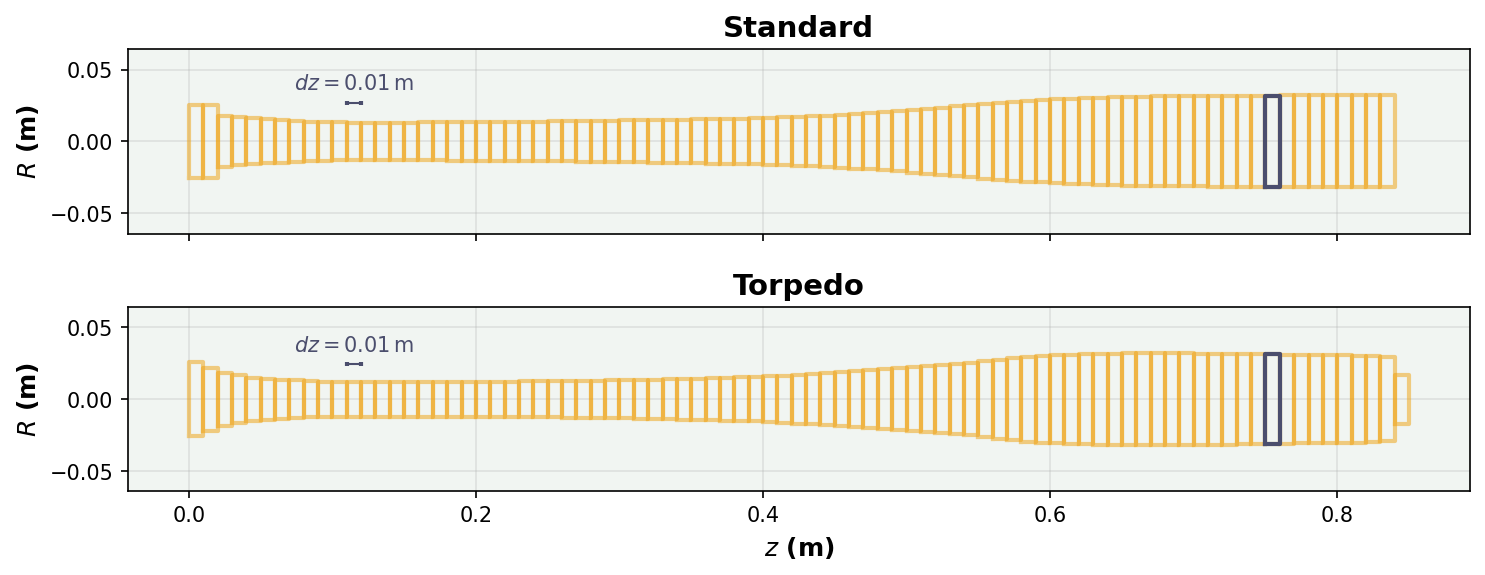

In [7]:
plot_bats_comparison(standard_bat, torpedo_bat, highlight=impact_idx)
plt.savefig('midterm_report/plots/bats.pdf')
plt.show()

In [8]:
#read hMatrix_torpedo.txt
with open('data/hMatrix_torpedo.txt', 'r') as f:
    h_matrix_torpedo = np.loadtxt(f)
dfH_t = pd.DataFrame(h_matrix_torpedo, columns = ['i', 'j', 'H_ij'])
#astype for i and j
dfH_t['i'] = dfH_t['i'].astype(int)
dfH_t['j'] = dfH_t['j'].astype(int)
#to csv
dfH_t.to_csv('data/H_matrix_torpedo.csv', index = False)

In [9]:
y0 = np.zeros(standard_bat.N)
Phi0 = np.zeros(standard_bat.N)
dy0 = np.zeros(standard_bat.N)
dPhi0 = np.zeros(standard_bat.N)

#set init displacement
y0[impact_idx] = 0.0001 #in m

psi0 = np.concatenate((y0, Phi0, dy0, dPhi0))
#initialize system for standard bat
standard_bat.set_initial_conditions(psi0)
standard_bat.H = load_H_matrix('data/H_matrix_navaNEW.csv')

#initialize system for torpedo bat (build its own initial conditions using torpedo_bat.N)
y0_t = np.zeros(torpedo_bat.N)
Phi0_t = np.zeros(torpedo_bat.N)
dy0_t = np.zeros(torpedo_bat.N)
dPhi0_t = np.zeros(torpedo_bat.N)
y0_t[impact_idx] = 0.0001 #in m

psi0_t = np.concatenate((y0_t, Phi0_t, dy0_t, dPhi0_t))
torpedo_bat.set_initial_conditions(psi0_t)
torpedo_bat.get_H_matrix()

#4th order yoshida

In [10]:
end_t = 0.05 # end time for integration in seconds
t_eval = np.linspace(0, end_t, 10000) # time evaluation points for integration

### Examine Eigenmodes ###

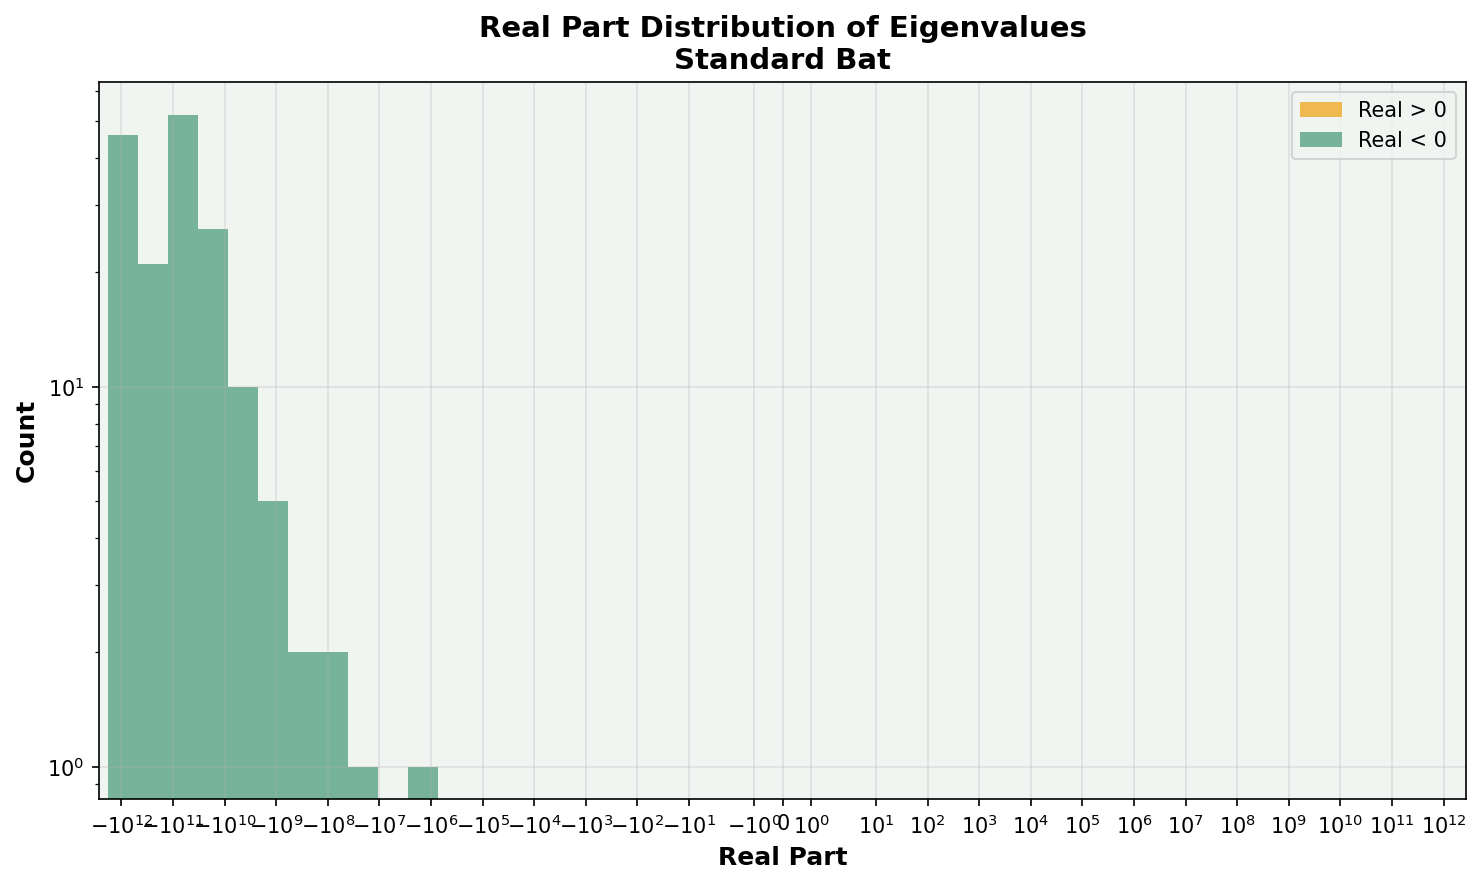

In [11]:
#hist of the H matrix eigvals for real and imaginary parts, log scale with even bins in log space
H_eigvals = np.linalg.eigvals(standard_bat.H)

fig, ax1 = plt.subplots(1, 1, figsize=(10, 6), sharex=True)

# Collect all nonzero magnitudes to determine shared symmetric x-limits
all_vals = np.concatenate([H_eigvals.real, H_eigvals.imag])
nonzero = np.abs(all_vals[all_vals != 0])
if len(
    nonzero) > 0:
    shared_max = nonzero.max() * 1.5
else:
    shared_max = 1.0

# Real part: log-spaced bins for positive and negative values separately
real_vals = H_eigvals.real
real_pos = real_vals[real_vals > 0]
real_neg = real_vals[real_vals < 0]

# Compute shared bin range from both sides so bins are symmetrical
all_abs = np.abs(real_vals[real_vals != 0])
shared_min = all_abs.min()
shared_bin_max = all_abs.max()
bins_log = np.logspace(np.log10(shared_min), np.log10(shared_bin_max), 30)
bins_pos = bins_log
bins_neg = -bins_log[::-1]

if len(real_pos) > 0:
    ax1.hist(real_pos, bins=bins_pos, alpha=0.7, label='Real > 0', color=colors[0])
if len(real_neg) > 0:
    ax1.hist(real_neg, bins=bins_neg, alpha=0.7, label='Real < 0', color=colors[1])
ax1.set_xscale('symlog')
ax1.set_xlabel('Real Part')
ax1.set_ylabel('Count')
ax1.set_xlim(-shared_max, shared_max)
ax1.legend()
ax1.set_yscale('log')
ax1.set_title('Real Part Distribution of Eigenvalues\nStandard Bat')

plt.tight_layout()
plt.show()

In [12]:
# are any eigvals with positive real part? If so, how many?
num_unstable = np.sum(H_eigvals.real > 0)
print(f'Number of eigenvalues with positive real part: {num_unstable}')
for num in range(num_unstable):
    print(f'Unstable eigenvalue {num+1}: {H_eigvals[H_eigvals.real > 0][num]:.2e}')

Number of eigenvalues with positive real part: 1
Unstable eigenvalue 1: 2.51e-05


In [13]:
evals, evecs = np.linalg.eig(standard_bat.H)

eig_df = pd.DataFrame({
    'eigenvalue': evals,
    'frequency_Hz': np.where(evals < 0, np.sqrt(-evals) / (2 * np.pi), np.nan),
    'eigenvector': list(evecs.T)
})

eig_df.sort_values('eigenvalue', ascending=False, inplace=True)
eig_df.reset_index(drop=True, inplace=True)
eig_df.to_csv('data/standard_bat_eigenvalues.csv', index=False)

/var/folders/9b/gcnbw5016f10hn50pnxmd2t40000gn/T/ipykernel_63262/2565695380.py:5: RuntimeWarning: invalid value encountered in sqrt
  'frequency_Hz': np.where(evals < 0, np.sqrt(-evals) / (2 * np.pi), np.nan),


/Users/navawolfish/Desktop/baseball/AlanProject/create_system_matrix.py:230: RuntimeWarning: invalid value encountered in sqrt
  'frequency_Hz': np.where(evals.real < 0, np.sqrt(-evals.real) / (2 * np.pi), 0),


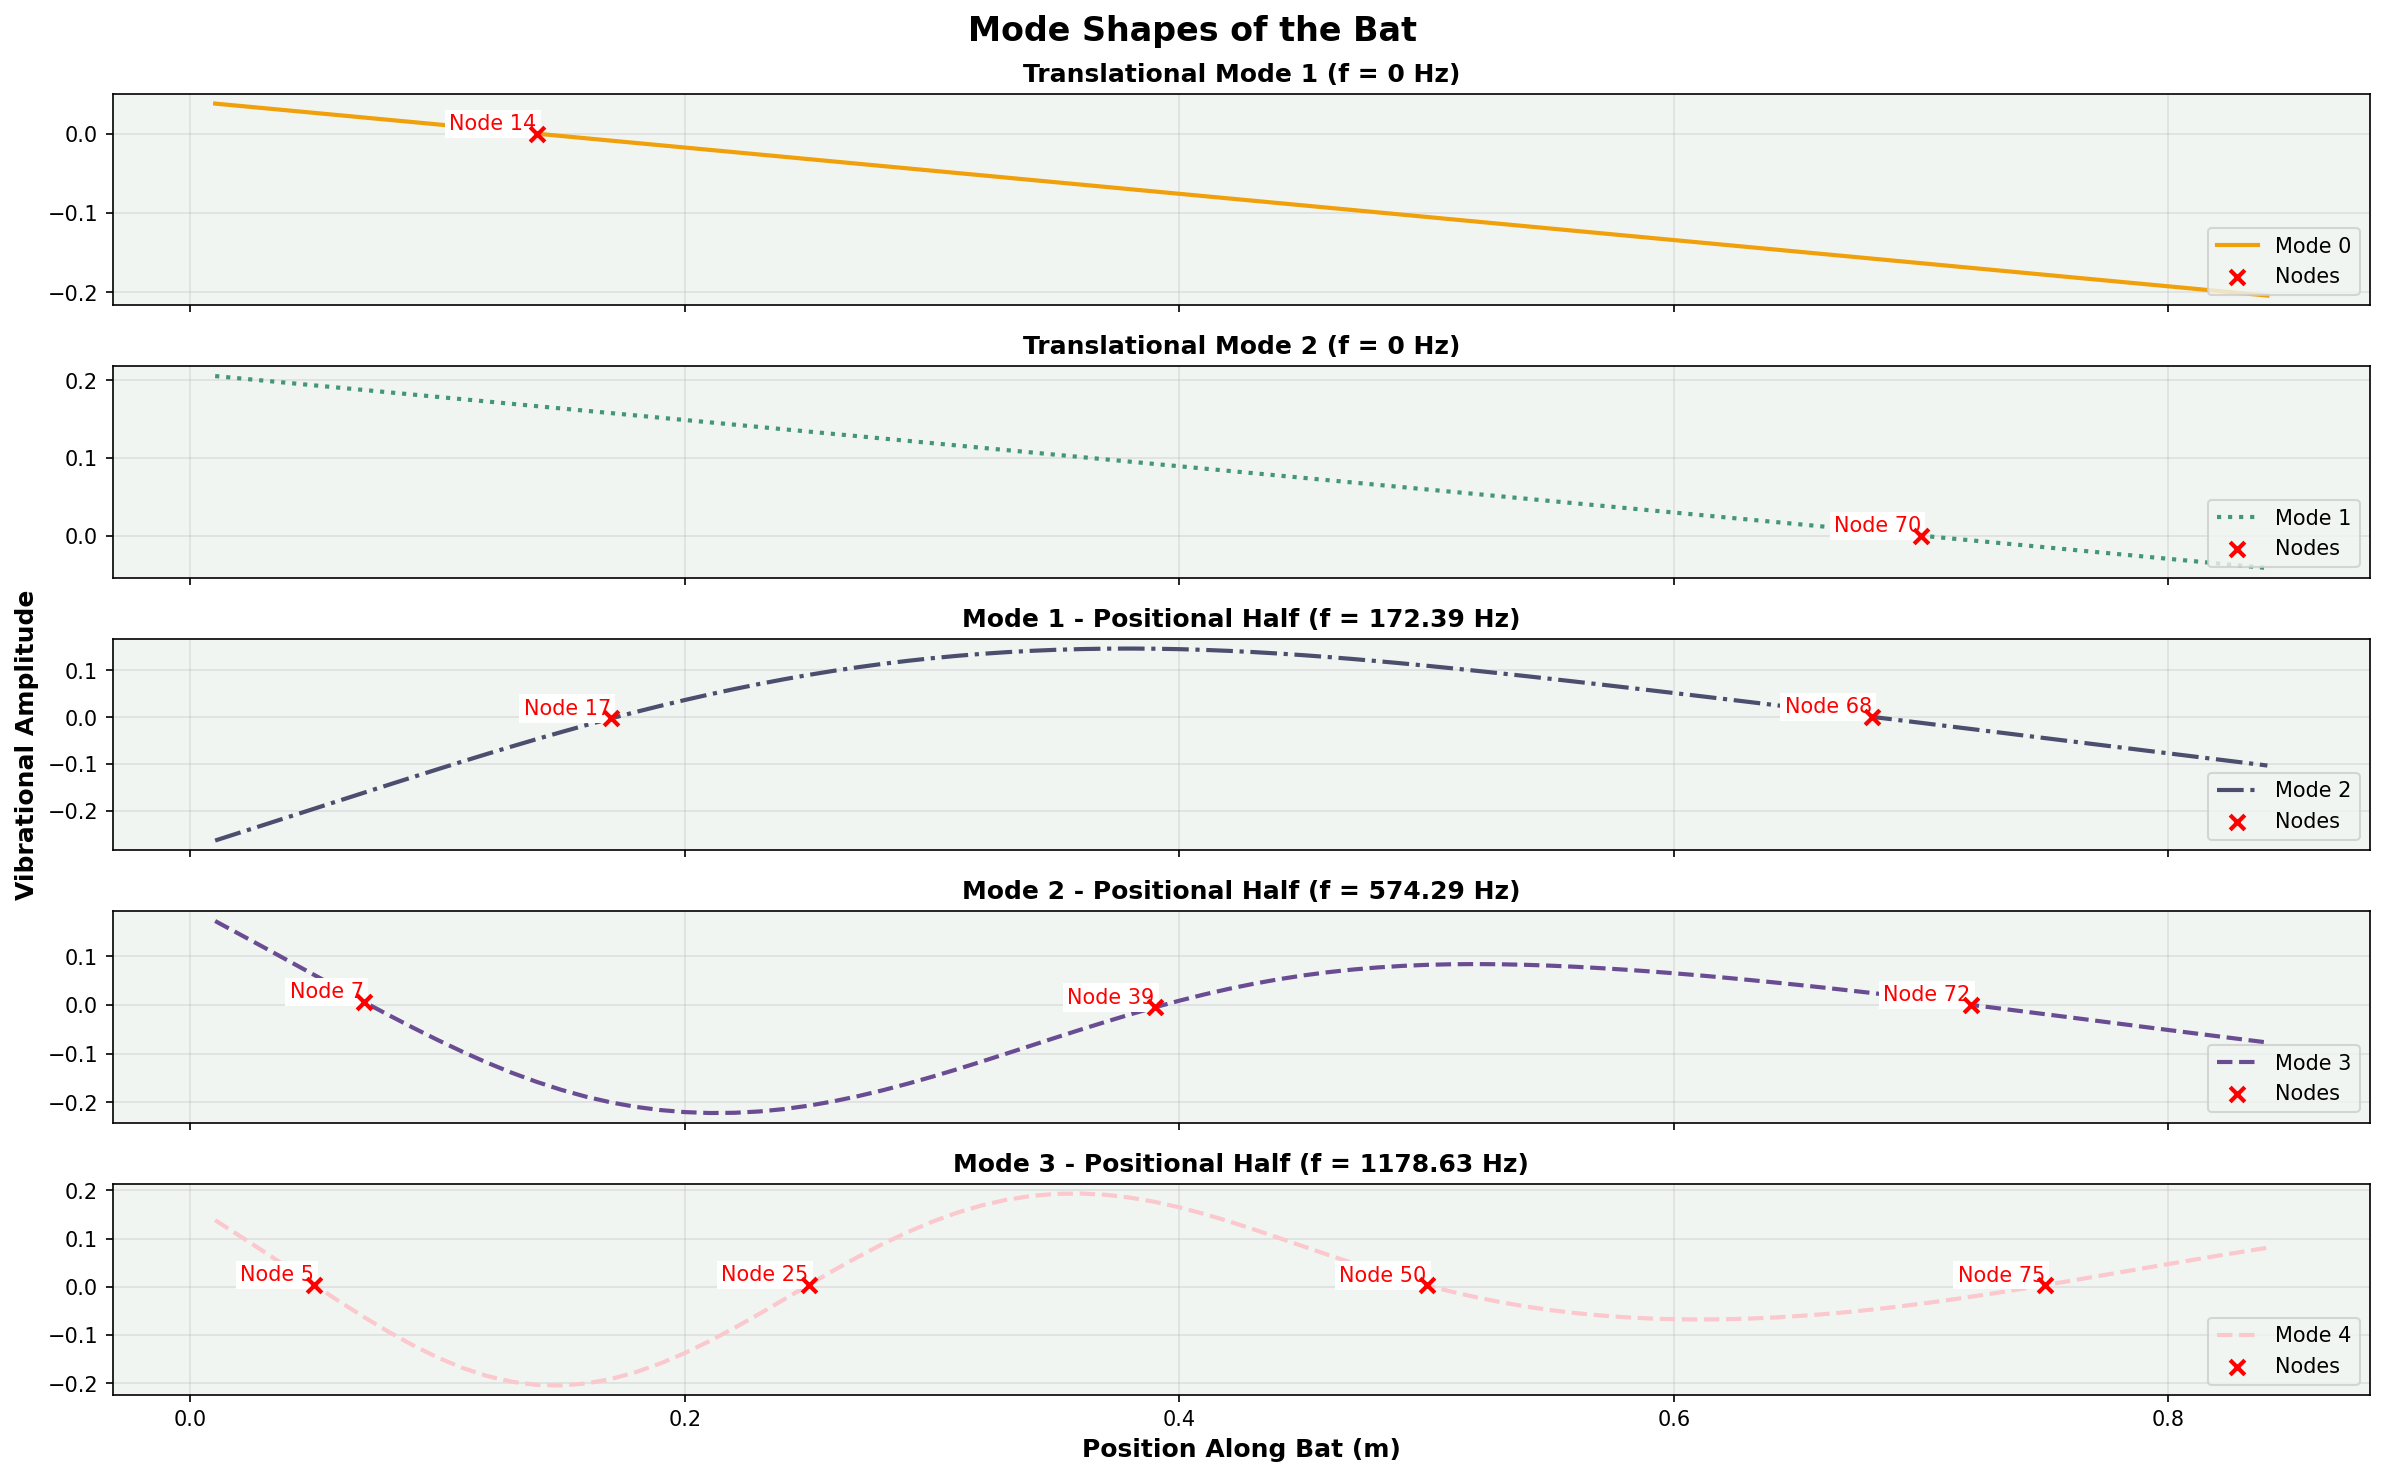

In [14]:
eig_df = compute_eigenfrequencies(standard_bat.H)
nodes = find_mode_nodes(eig_df, standard_bat.zs, standard_bat.N)
plot_mode_shapes(eig_df, standard_bat.zs, standard_bat.N, num_modes=5)
plt.show()

### Integrate Solution ### 

In [15]:
sol = standard_bat.integrate_solution((0, end_t), t_eval)

In [16]:
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.001e-06 ...  4.999e-02  5.000e-02]
        y: [[ 0.000e+00  0.000e+00 ... -5.026e-06 -2.016e-06]
            [ 0.000e+00  0.000e+00 ... -9.594e-06 -1.315e-05]
            ...
            [ 0.000e+00  1.835e-05 ...  8.701e-02 -1.107e-01]
            [ 0.000e+00  6.603e-07 ... -2.099e-02 -5.377e-02]]
      sol: None
 t_events: None
 y_events: None
     nfev: 1001174
     njev: 0
      nlu: 0

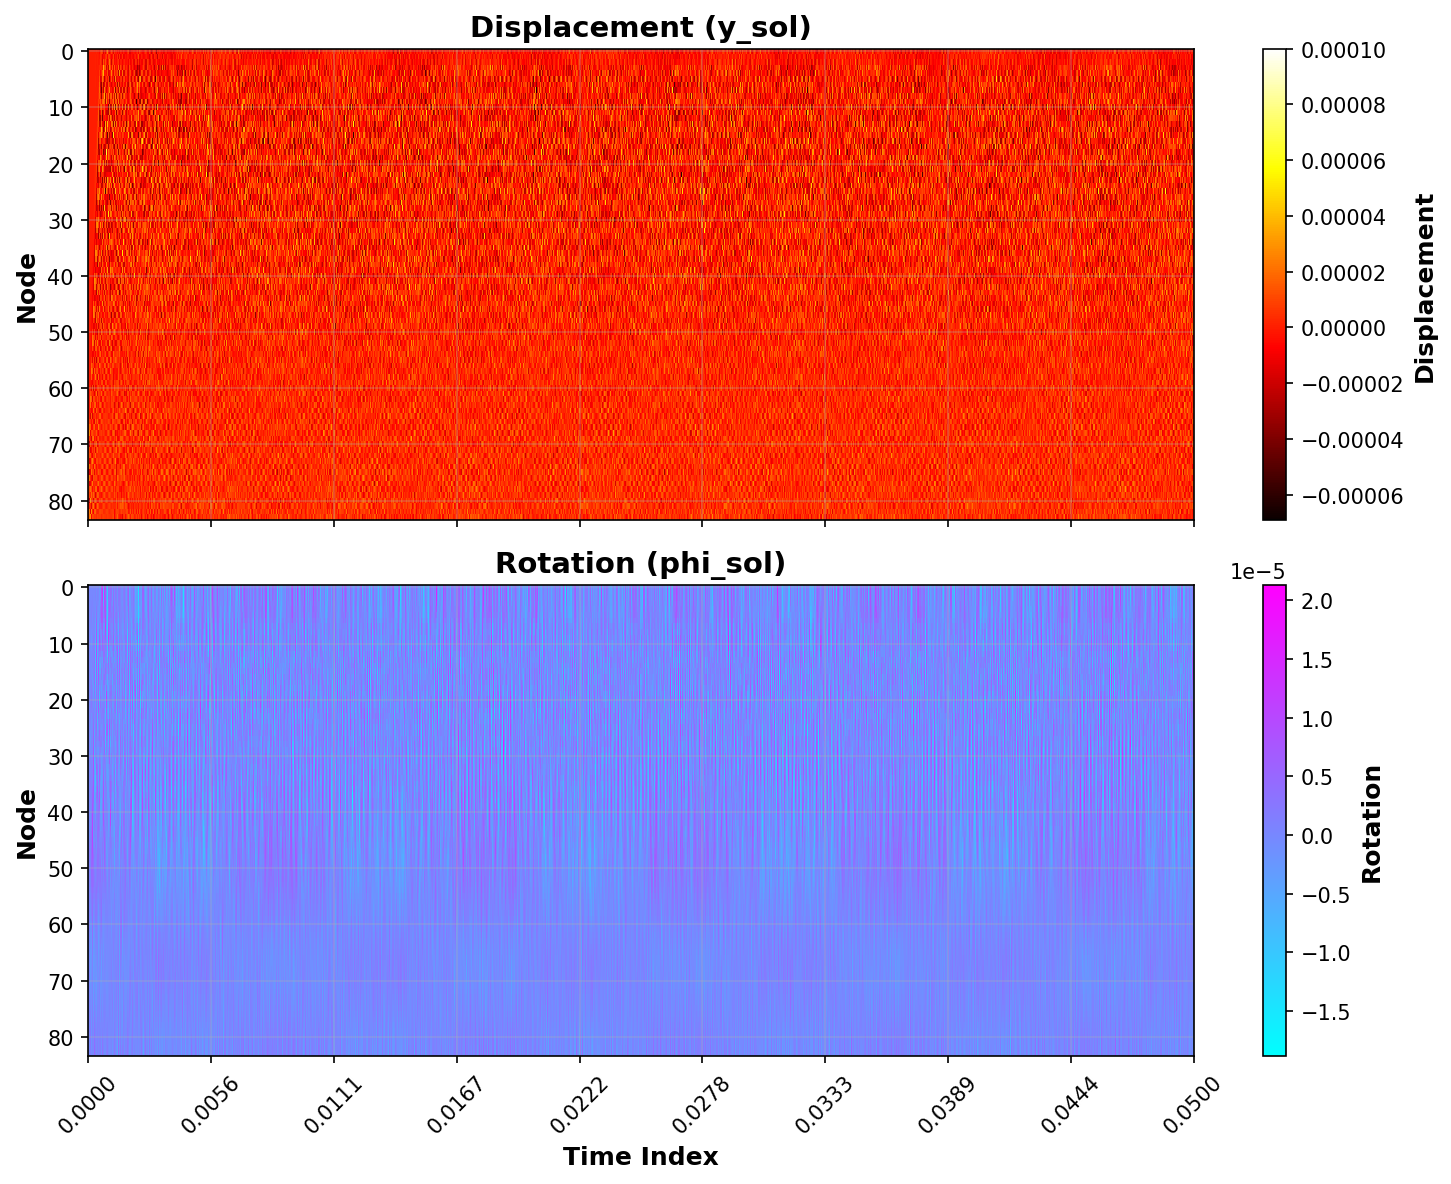

In [18]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# y_sol subplot
im0 = axs[0].imshow(standard_bat.y_sol, cmap='hot', interpolation='nearest', aspect='auto')
axs[0].set_ylabel('Node')
axs[0].set_title('Displacement (y_sol)')
plt.colorbar(im0, ax=axs[0], label='Displacement')
# phi_sol subplot
im1 = axs[1].imshow(standard_bat.phi_sol, cmap='cool', interpolation='nearest', aspect='auto')
axs[1].set_xlabel('Time Index')
axs[1].set_ylabel('Node')
axs[1].set_title('Rotation (phi_sol)')
plt.colorbar(im1, ax=axs[1], label='Rotation')
# Set x-ticks to correspond to time points in standard_bat.t
num_ticks = 10
if hasattr(standard_bat, 't') and len(standard_bat.t) > 1:
    xtick_locs = np.linspace(0, len(standard_bat.t)-1, num_ticks, dtype=int)
    xtick_labels = [f"{standard_bat.t[i]:.4f}" for i in xtick_locs]
    axs[1].set_xticks(xtick_locs)
    axs[1].set_xticklabels(xtick_labels, rotation=45)
plt.tight_layout()
plt.show()

### Fourier

First, compute the expected frequencies from the H matrix

In [19]:
## print H matrix eigenvalues
H = load_H_matrix('data/H_matrix_navaNEW.csv')

eigenvalues, _ = np.linalg.eig(H)
omega = np.sqrt(-eigenvalues) / (2 * np.pi) # convert to frequencies in Hz

Alan_freqs = [165, 586, 1177, 1851, 2580, 3359, 4163, 4972, 5783, 6598]
#sort omega
omega = np.sort(omega)



print("First 10 frequencies of H matrix, Hz:")
print(omega[:10])
print("Alan's frequencies, Hz:")
print(Alan_freqs)

#divide component-wise by Alan's frequencies to get relative error
rel_error = np.abs((omega[:10] - np.array(Alan_freqs)) / np.array(Alan_freqs))
print("Relative error:")
print(rel_error)


First 10 frequencies of H matrix, Hz:
[7.07109489e-04 1.72387848e+02 5.74293413e+02 1.17863488e+03
 1.84702809e+03 2.57747080e+03 3.35896846e+03 4.16323413e+03
 4.97410137e+03 5.79398345e+03]
Alan's frequencies, Hz:
[165, 586, 1177, 1851, 2580, 3359, 4163, 4972, 5783, 6598]
Relative error:
[0.99999571 0.70582279 0.51207017 0.36324426 0.28409764 0.23266722
 0.19313753 0.16266409 0.13987526 0.12185762]


/var/folders/9b/gcnbw5016f10hn50pnxmd2t40000gn/T/ipykernel_63262/121862784.py:5: RuntimeWarning: invalid value encountered in sqrt
  omega = np.sqrt(-eigenvalues) / (2 * np.pi) # convert to frequencies in Hz


In [20]:
dt = standard_bat.t[1] - standard_bat.t[0]
print(f"Time step used in integration: {dt} seconds")
nyquist = 1 / (2 * dt)
print(f"Nyquist frequency: {nyquist} Hz")

Time step used in integration: 5.000500050005001e-06 seconds
Nyquist frequency: 99990.0 Hz


In [21]:
# %% Fourier
bat_fft = np.fft.fft(standard_bat.y_sol, axis=1) #take fft along time axis
ntime = len(standard_bat.t) 
freqs = np.fft.fftfreq(ntime, d= standard_bat.t[1] - standard_bat.t[0]) #frequency bins corresponding to FFT components

# Compute amplitude spectrum
amplitude = np.abs(bat_fft[:, 0:ntime//2])
freqs_pos = freqs[0:ntime//2] #positive frequencies


# Average amplitude across all nodes
mean_amplitude = amplitude.mean(axis=0)


freqs_pos_mask = freqs_pos < 1000 #only look at frequencies below 1000 Hz
new_freqs = freqs_pos[freqs_pos_mask]
mean_amplitude = mean_amplitude[freqs_pos_mask]

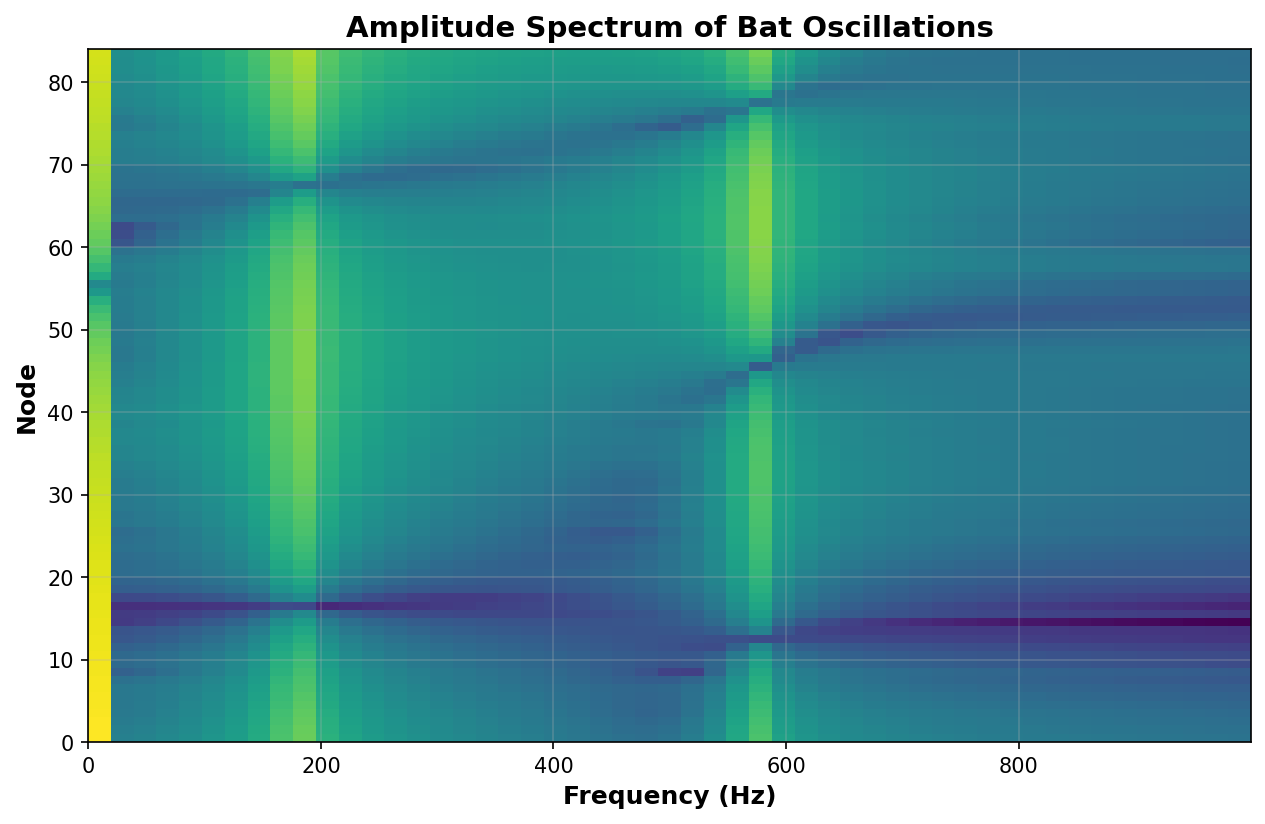

In [22]:
# Plot the fft
cmap = plt.get_cmap('viridis').colors[:len(amplitude)] # get a subset of the colormap for the number of frequencies

log_amp = np.log10(amplitude + 1e-10) # add small value to avoid log(0)
plt.imshow(log_amp[:, freqs_pos_mask], extent=(new_freqs[0], new_freqs[-1], 0, amplitude.shape[0]), aspect='auto', cmap='viridis')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Node')
plt.title('Amplitude Spectrum of Bat Oscillations')
plt.show()

In [23]:
#find peaks in the residuals 
peaks, _ = find_peaks(mean_amplitude) # only consider peaks with height > 5%
print("Significant peaks in spectrum at frequencies (Hz):")
for peak in peaks:
    print(f"{new_freqs[peak]:.2f} Hz with amplitude {mean_amplitude[peak]:.4f}")

centroids = []
print("Centroid frequencies of significant peaks (Hz):")
for peak in peaks:
    # Define a window around the peak for centroid calculation
    window = 5  # number of points on each side
    left = max(peak - window, 0)
    right = min(peak + window + 1, len(mean_amplitude))
    amp_window = mean_amplitude[left:right]
    freq_window = new_freqs[left:right]
    # Centroid calculation (center of mass)
    centroid = np.sum(freq_window * amp_window) / np.sum(amp_window)
    centroids.append(centroid)
    print(f"Peak at {new_freqs[peak]:.2f} Hz, centroid: {centroid:.2f} Hz, amplitude: {mean_amplitude[peak]:.4f}")
centroids = np.array(centroids)

Significant peaks in spectrum at frequencies (Hz):
179.98 Hz with amplitude 0.0050
579.94 Hz with amplitude 0.0035
Centroid frequencies of significant peaks (Hz):
Peak at 179.98 Hz, centroid: 178.49 Hz, amplitude: 0.0050
Peak at 579.94 Hz, centroid: 576.58 Hz, amplitude: 0.0035


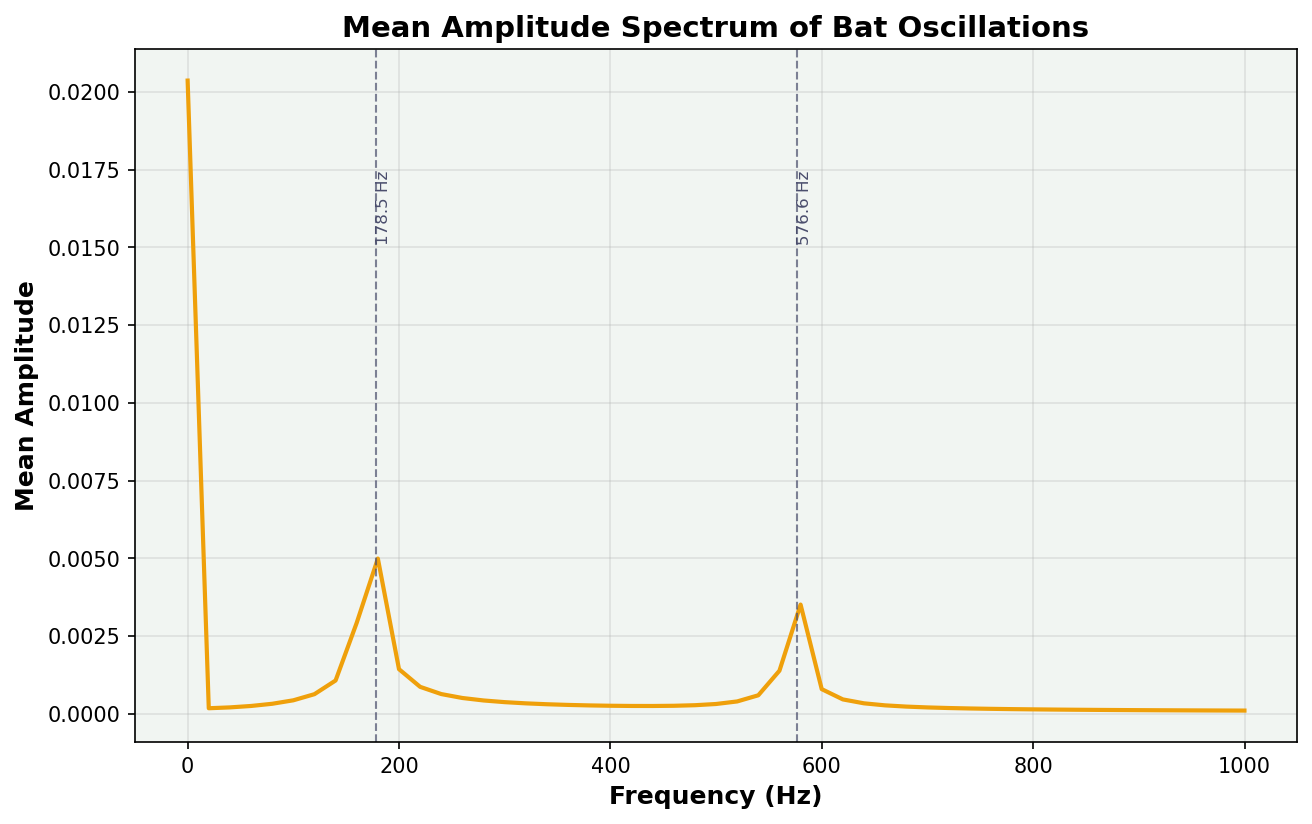

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(new_freqs, mean_amplitude, label='Mean Amplitude Spectrum', color = colors[0])
for centroid in centroids:
    plt.axvline(x=centroid, color=colors[2], linestyle='--', alpha=0.7, label=f'Centroid: {centroid:.2f} Hz', linewidth = 1)
    plt.text(centroid, max(mean_amplitude)*0.8, f'{centroid:.1f} Hz', rotation=90, verticalalignment='center', color=colors[2], fontsize=8)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Mean Amplitude')
plt.title('Mean Amplitude Spectrum of Bat Oscillations')
plt.show()

## Animate

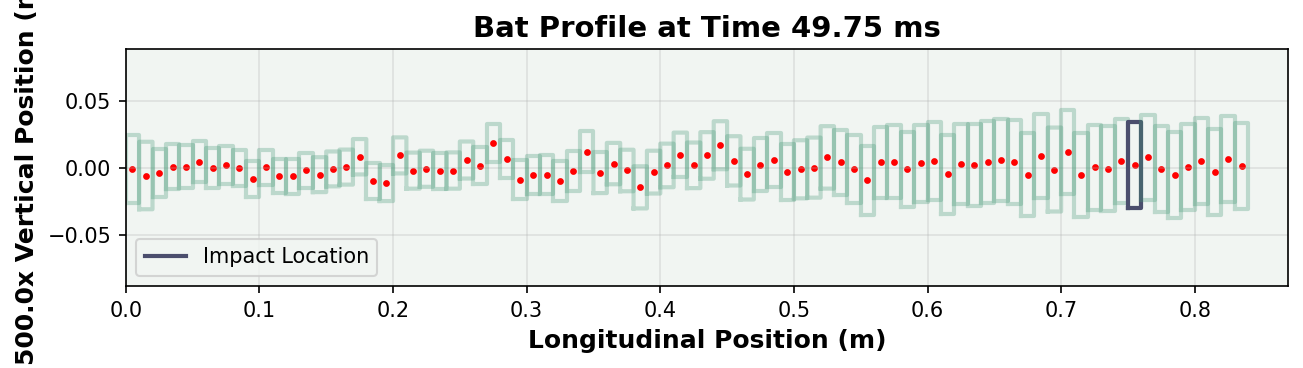

In [25]:
standard_bat.animate_bat(exaggerate=500.0, interval=50, path = f'midterm_report/plots/collision_at_{impact_idx}.mp4', idx = impact_idx)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/navawolfish/Desktop/baseball/AlanProject/plots'

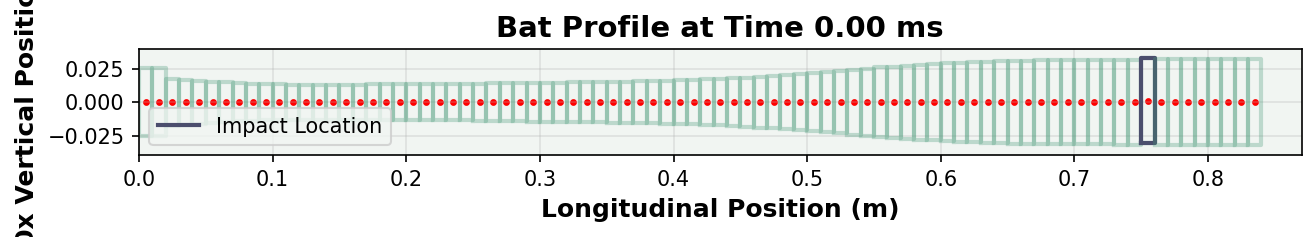

In [52]:
standard_bat.animate_bat(exaggerate=10.0, interval=100, path = f'plots/collision_at_{impact_idx}_10x.mp4', idx = impact_idx)

## Colliding bat

In [ ]:
col_bat = BatOsc(bat_prof_s, 0.01)
col_bat.set_bat_features(mass_s, rho_s, Y_s, S_s) # in kg, kg/m^3, N/m^2, N/m^2, setting the bat features for integration

In [ ]:
# inits
y0 = np.zeros(col_bat.N)
Phi0 = np.zeros(col_bat.N)
dy0 = np.zeros(col_bat.N)
dPhi0 = np.zeros(col_bat.N)

psi0 = np.concatenate((y0, Phi0, dy0, dPhi0))
col_bat.set_initial_conditions(psi0)
col_bat.get_H_matrix('data/H_matrix_navaNEW.csv')

In [ ]:
# force profile for collision
def force_profile_gaus(t, slice):
    if not isinstance(t, np.ndarray):
        t = np.array([t])
        print(t.shape)
    F = np.zeros((2*col_bat.N, t.shape[0]))
    print(F.shape)
    # Simple Gaussian force profile centered at 4 ms with a width of 0.5 ms and a peak force of 1000 N
    F_peak = 15000  # Peak force in Newtons
    t_center = 0.004  # Center time of the collision in seconds
    width = 0.0005  # Width of the force profile in seconds
    F[slice] = F_peak * np.exp(-0.5 * ((t - t_center) / width)**2)
    return F

In [ ]:
def F_constant(t, t_max, slice, mag):
    if not isinstance(t, np.ndarray):
        t = np.array([t])
    F_array = np.zeros((2*col_bat.N, len(t)))
    for i, time in enumerate(t):
        if time <= t_max:
            F_array[slice, i] = mag
    return F_array

In [ ]:
F = lambda t: F_constant(t, 0.001, 75, -10000) # be careful about the max time -> no more than 1ms

end_t = 0.5 # end time for integration in seconds
t_eval = np.linspace(0, end_t, 10000) # time evaluation points for integration

sol = col_bat.integrate_solution_with_collision((0, end_t), F, t_eval)

In [ ]:
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.001e-05 ...  4.999e-01  5.000e-01]
        y: [[ 0.000e+00  1.067e-65 ... -1.162e-01 -1.162e-01]
            [ 0.000e+00  3.581e-64 ... -1.162e-01 -1.162e-01]
            ...
            [ 0.000e+00 -5.334e-03 ... -1.186e-03  3.512e-03]
            [ 0.000e+00 -5.372e-03 ... -1.349e-03  3.702e-03]]
      sol: None
 t_events: None
 y_events: None
     nfev: 5844764
     njev: 0
      nlu: 0

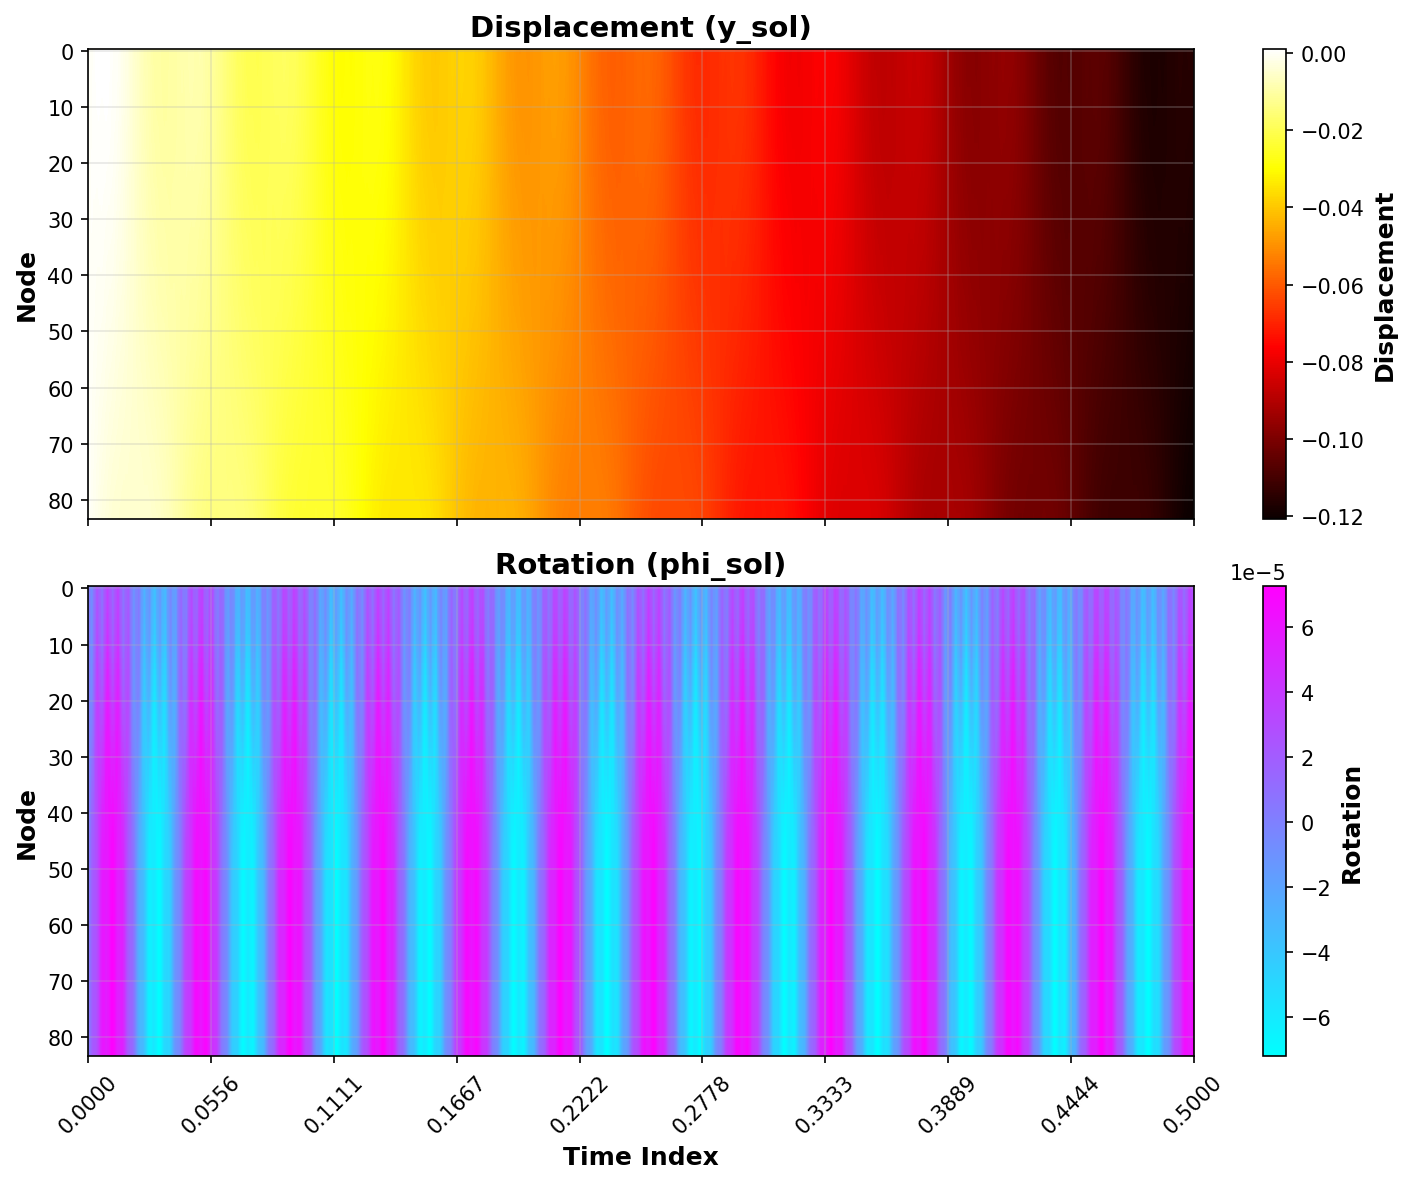

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# y_sol subplot
im0 = axs[0].imshow(col_bat.y_sol, cmap='hot', interpolation='nearest', aspect='auto')
axs[0].set_ylabel('Node')
axs[0].set_title('Displacement (y_sol)')
plt.colorbar(im0, ax=axs[0], label='Displacement')
# phi_sol subplot
im1 = axs[1].imshow(col_bat.phi_sol, cmap='cool', interpolation='nearest', aspect='auto')
axs[1].set_xlabel('Time Index')
axs[1].set_ylabel('Node')
axs[1].set_title('Rotation (phi_sol)')
plt.colorbar(im1, ax=axs[1], label='Rotation')
# Set x-ticks to correspond to time points in col_bat.t
num_ticks = 10
if hasattr(col_bat, 't') and len(col_bat.t) > 1:
    xtick_locs = np.linspace(0, len(col_bat.t)-1, num_ticks, dtype=int)
    xtick_labels = [f"{col_bat.t[i]:.4f}" for i in xtick_locs]
    axs[1].set_xticks(xtick_locs)
    axs[1].set_xticklabels(xtick_labels, rotation=45)
plt.tight_layout()
plt.show()

### Fourier Analysis

In [ ]:
# %% Fourier
bat_fft = np.fft.fft(col_bat.phi_sol, axis=1) #take fft along time axis
ntime = len(col_bat.t) 
freqs = np.fft.fftfreq(ntime, d= col_bat.t[1] - col_bat.t[0]) #frequency bins corresponding to FFT components

# Compute amplitude spectrum
amplitude = np.abs(bat_fft[:, 0:ntime//2])
freqs_pos = freqs[0:ntime//2] #positive frequencies


# Average amplitude across all nodes
mean_amplitude = amplitude.mean(axis=0)


freqs_pos_mask = freqs_pos < 1000 #only look at frequencies below 1000 Hz
new_freqs = freqs_pos[freqs_pos_mask]
mean_amplitude = mean_amplitude[freqs_pos_mask]

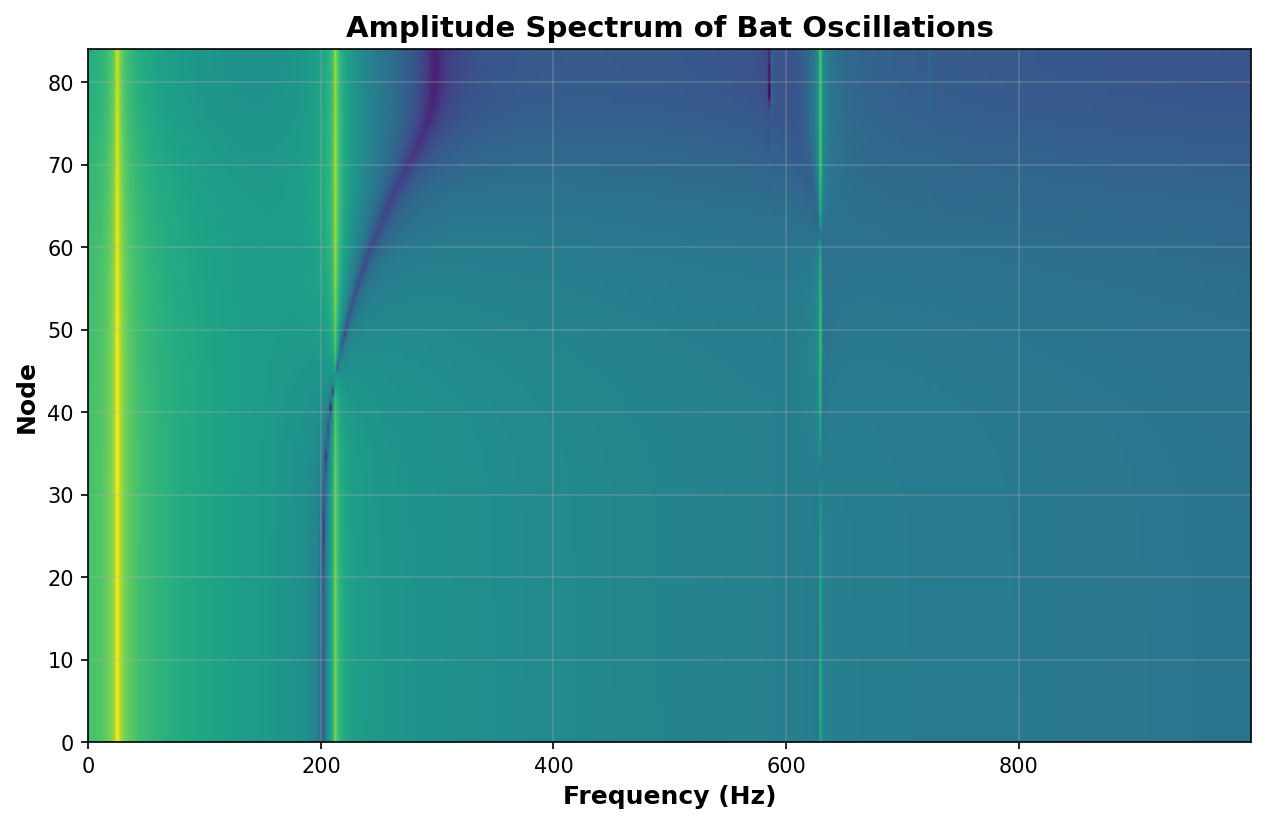

In [ ]:
# Plot the fft
cmap = plt.get_cmap('viridis').colors[:len(amplitude)] # get a subset of the colormap for the number of frequencies

log_amp = np.log10(amplitude + 1e-10) # add small value to avoid log(0)
plt.imshow(log_amp[:, freqs_pos_mask], extent=(new_freqs[0], new_freqs[-1], 0, amplitude.shape[0]), aspect='auto', cmap='viridis')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Node')
plt.title('Amplitude Spectrum of Bat Oscillations')
plt.show()

In [ ]:
#find peaks in the residuals 
peaks, _ = find_peaks(mean_amplitude) # only consider peaks with height > 5%
print("Significant peaks in spectrum at frequencies (Hz):")
for peak in peaks:
    print(f"{new_freqs[peak]:.2f} Hz with amplitude {mean_amplitude[peak]:.4f}")

centroids = []
print("Centroid frequencies of significant peaks (Hz):")
for peak in peaks:
    # Define a window around the peak for centroid calculation
    window = 5  # number of points on each side
    left = max(peak - window, 0)
    right = min(peak + window + 1, len(mean_amplitude))
    amp_window = mean_amplitude[left:right]
    freq_window = new_freqs[left:right]
    # Centroid calculation (center of mass)
    centroid = np.sum(freq_window * amp_window) / np.sum(amp_window)
    centroids.append(centroid)
    print(f"Peak at {new_freqs[peak]:.2f} Hz, centroid: {centroid:.2f} Hz, amplitude: {mean_amplitude[peak]:.4f}")
centroids = np.array(centroids)

Significant peaks in spectrum at frequencies (Hz):
24.00 Hz with amplitude 0.2443
211.98 Hz with amplitude 0.0291
587.94 Hz with amplitude 0.0003
629.94 Hz with amplitude 0.0047
723.93 Hz with amplitude 0.0002
Centroid frequencies of significant peaks (Hz):
Peak at 24.00 Hz, centroid: 24.30 Hz, amplitude: 0.2443
Peak at 211.98 Hz, centroid: 212.45 Hz, amplitude: 0.0291
Peak at 587.94 Hz, centroid: 587.87 Hz, amplitude: 0.0003
Peak at 629.94 Hz, centroid: 629.94 Hz, amplitude: 0.0047
Peak at 723.93 Hz, centroid: 723.87 Hz, amplitude: 0.0002


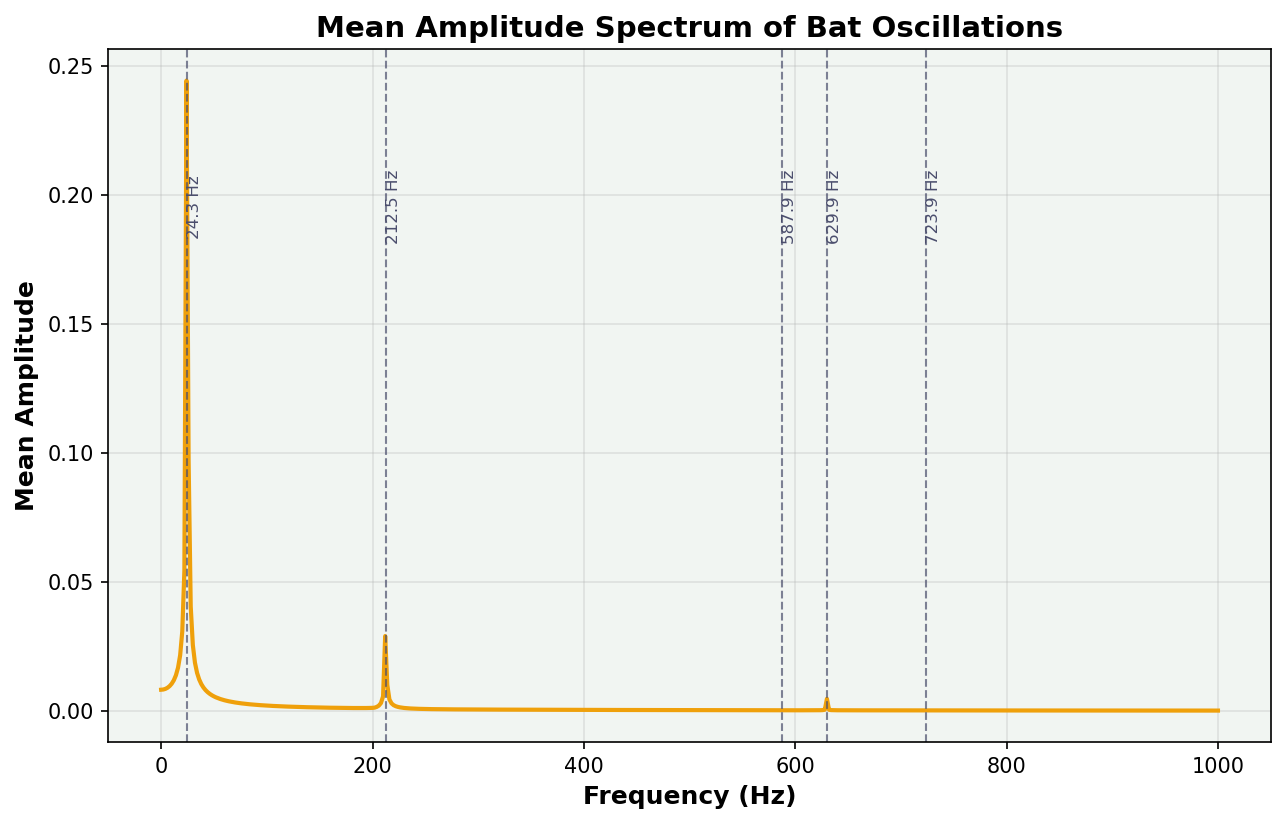

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(new_freqs, mean_amplitude, label='Mean Amplitude Spectrum', color = colors[0])
for centroid in centroids:
    plt.axvline(x=centroid, color=colors[2], linestyle='--', alpha=0.7, label=f'Centroid: {centroid:.2f} Hz', linewidth = 1)
    plt.text(centroid, max(mean_amplitude)*0.8, f'{centroid:.1f} Hz', rotation=90, verticalalignment='center', color=colors[2], fontsize=8)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Mean Amplitude')
plt.title('Mean Amplitude Spectrum of Bat Oscillations')
plt.show()

## **Ball**

In [ ]:
def hysteresis_curve(u, k = 6.533107, alpha = 1.84):
    """ Force required to achieve compression u, with stiffness k and nonlinearity alpha. Model for the baseball.
    Parameters:
    u: compression distance (m)
    k: stiffness coefficient (N/m^alpha)
    alpha: nonlinearity exponent (dimensionless)
    Returns:
    Force (N) required to achieve compression u
    """
    return k * u ** alpha